# Airline Sentiment — Text Preprocessing & Baseline Model

**Goal:** Convert cleaned tweet text into TF-IDF features, set up a stratified train/test
split, and train a Logistic Regression baseline for 3-class sentiment classification.

Sections:
1. Load and clean data
2. Stratified train/test split
3. TF-IDF vectorization
4. Baseline model: Logistic Regression
5. Evaluation (macro-F1, per-class metrics, confusion matrix)
6. Inspect misclassified examples
7. Key takeaways

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)
RANDOM_STATE = 42

## 1. Load and Clean Data

Same cleaning as notebook 01, repeated here so this notebook can run independently.

In [2]:
df = pd.read_csv('archive/Tweets.csv')

def clean_tweet(text):
    text = str(text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'&\w+;', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

df['text_clean'] = df['text'].apply(clean_tweet)

# Drop any rows where cleaning left an empty string (rare, but possible for very short tweets)
df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)
print(df.shape)

(14640, 16)


## 2. Stratified Train/Test Split

Stratify on sentiment so the 62.7% / 21.2% / 16.1% class balance is preserved in both
train and test sets, same principle used in the diabetes project.

In [3]:
X = df['text_clean']
y = df['airline_sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print('Train:', X_train.shape, ' Test:', X_test.shape)
print('\nTrain class balance:')
print(y_train.value_counts(normalize=True).round(3))

Train: (11712,)  Test: (2928,)

Train class balance:
airline_sentiment
negative    0.627
neutral     0.212
positive    0.161
Name: proportion, dtype: float64


## 3. TF-IDF Vectorization

Fit the vectorizer on TRAIN only, then transform both train and test — same leakage principle
as scaling numeric features in the earlier projects. `max_features` caps vocabulary size to
keep things fast; `min_df` drops extremely rare words that are more noise than signal;
`ngram_range=(1, 2)` includes both single words and two-word phrases (e.g. 'customer service').

In [4]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=3,
    ngram_range=(1, 2),
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print('TF-IDF matrix shape (train):', X_train_tfidf.shape)
print('Vocabulary size:', len(vectorizer.vocabulary_))

TF-IDF matrix shape (train): (11712, 5000)
Vocabulary size: 5000


In [5]:
# Peek at a sample of the learned vocabulary
import random
sample_terms = random.sample(list(vectorizer.vocabulary_.keys()), 20)
print(sample_terms)

['sound', 'accounts', 'existing', 'minute hold', 'ny', 've flown', 'neveragain', 'flier', 'flight ll', 'day vacation', 'moments', 'sent email', 'guys need', 'phone number', 'merged', 'dallas austin', 'compensate', 'designed', 'keeps', 'online flight']


## 4. Baseline Model: Logistic Regression

`class_weight='balanced'` handles the class imbalance, same approach used for the diabetes
project's baseline.

In [6]:
baseline_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

baseline_model.fit(X_train_tfidf, y_train)

y_pred = baseline_model.predict(X_test_tfidf)

## 5. Evaluation

This is a 3-class problem, so use macro-F1 (averages F1 across all three classes equally,
regardless of how many examples each has) alongside the full classification report.

In [7]:
print(classification_report(y_test, y_pred))

macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f'Macro F1: {macro_f1:.3f}')

              precision    recall  f1-score   support

    negative       0.89      0.78      0.83      1835
     neutral       0.52      0.70      0.60       620
    positive       0.67      0.69      0.68       473

    accuracy                           0.75      2928
   macro avg       0.69      0.72      0.70      2928
weighted avg       0.78      0.75      0.76      2928

Macro F1: 0.704


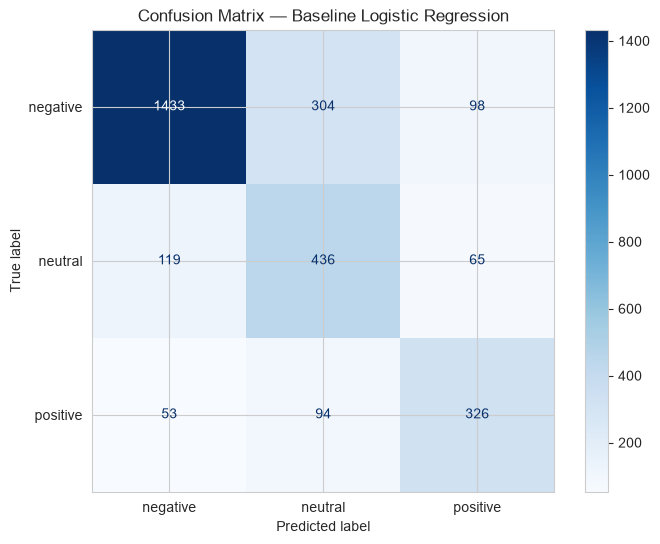

In [8]:
cm = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'neutral', 'positive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Baseline Logistic Regression')
plt.show()

## 6. Inspect Misclassified Examples

Reading actual mistakes is one of the most useful things you can do with a text classifier,
it often reveals patterns a confusion matrix alone can't (sarcasm, mixed sentiment, short
ambiguous tweets, etc.).

In [9]:
results_df = pd.DataFrame({
    'text': X_test.values,
    'actual': y_test.values,
    'predicted': y_pred
})

misclassified = results_df[results_df['actual'] != results_df['predicted']]
print(f'{len(misclassified)} misclassified out of {len(results_df)} ({len(misclassified)/len(results_df):.1%})')

# Look at a sample of negative tweets predicted as positive (or vice versa) -- the most
# interesting errors, since neutral confusion is less surprising
interesting_errors = misclassified[
    ((misclassified['actual'] == 'negative') & (misclassified['predicted'] == 'positive')) |
    ((misclassified['actual'] == 'positive') & (misclassified['predicted'] == 'negative'))
]
interesting_errors.head(10)

733 misclassified out of 2928 (25.0%)


,text,actual,predicted
12,of course but they were just as helpless as ev...,negative,positive
14,no oscars on direct tv on this flight we were ...,negative,positive
18,well i did miss it but gate agents had rebooke...,positive,negative
53,i get can appreciate that i ve just had so man...,negative,positive
83,we appreciate the shoutout for roberto dm conf...,negative,positive
99,i ve never had anything bad to say until now n...,negative,positive
110,stellar customer service you have earned my bu...,positive,negative
143,and also it s great that you tweet complainers...,negative,positive
151,thanks for updating me about the hour delay th...,positive,negative
159,is elp friendly flyerfriendly united emb elpaso,positive,negative
